# Step 6 — Evaluation & Monitoring (MLOps & LLMOps)

In a production system, we cannot wait for delayed ground-truth to understand if our ML model or GenAI explanations are degrading. This notebook demonstrates how to monitor the system using synthetic logs and artifact metadata.

We will cover the lifecycle in terms of timeline and flow:
1. **Time T0: Model Deployment (Historical Metrics)** - Retrieving baseline metrics from our training artifacts.
2. **Time T1: Live Traffic (New Data Drift)** - Real-time monitoring proxies to catch feature, concept, and GenAI drift.
3. **Time T2: Model Updates & Retraining** - Handling drift when the model and historical data change.
4. **The "Golden Set" / Canary Testing Approach** - Catching immediate degradation.

### Generate evaluation logs (ML scores + GenAI explanations)

**ML prediction logs.** The script loads `claim_use_case_dataset.xlsx`, draws random rows for a historical window and a drifted “live” window (with inflated `rrp` / `excessFee` on the live split), and runs the trained pipeline via `predict_batch`. Each logged row stores `predicted_prob`, `ml_approved`, ground-truth approval from `status`, and feature snapshots.

**GenAI explanations.** For each row the script builds a `ClaimInput` from the spreadsheet row (`dataframe_row_to_claim`), then calls the LLM twice per claim—**`customer`** (external email–style) and **`claims_adjuster`** (internal review with model-facing framing)—using the same decision context as the API: `approved`, `probability_approved`, `risk_band`, plus top model features. Results are stored in `genai_explanation_customer` and `genai_explanation_adjuster`. The column `genai_explanation` is a duplicate of the customer text for backward compatibility with older notebook cells. Either column may be replaced synthetically to simulate bad explanations / drift.

**Outputs & rate limits.** CSV files live under `data/`. The explanation cache is `data/eval_genai_explain_cache.json` (`EVAL_GENAI_EXPLAIN_CACHE` to override). **Run the generator from this notebook in-process** (`await generate_logs()` in the code cell) so **tqdm and `[gemini]` heartbeats show**; a plain subprocess often buffers output so the bar looks frozen.

**Gemini / Gemma batching:** Defaults use **100 rows per split** (`EVAL_LOG_SAMPLE_SIZE`). The hosted model defaults to **`gemma-4-31b-it`** via `GEMINI_MODEL` in `.env` / `app.config.Settings` (same `generateContent` API as Gemini). With **`EVAL_GEMINI_RPD_BUDGET`** set (e.g. **1500**), auto batch size is **`max(ceil(slots/rpd), min(EVAL_EXPLAIN_BATCH_MAX, slots))`** — fewer, larger requests until **`EVAL_EXPLAIN_BATCH_MAX`** (default **20**, overridable) to avoid one enormous prompt; if RPD is tighter than that cap allows, the script raises batch size and warns. With RPD **off**, auto batch size is **`min(EVAL_EXPLAIN_BATCH_MAX, slots)`** unless **`EVAL_EXPLAIN_BATCH_SIZE`** is set; use **`EVAL_EXPLAIN_BATCH_SIZE_FALLBACK`** only if you want a smaller batch (e.g. **8**). Set **`GEMINI_RPM=15`** (not **15000**) or **`GEMINI_MIN_REQUEST_INTERVAL_S≈4`** so spacing matches a typical **15 RPM** tier. `EVAL_GEMINI_TIMEOUT_S` defaults to **240**.

**How many log “types” in production?** The FastAPI app emits **two** structured JSON-line event kinds: `event: prediction` (every `/v1/predict` and the predict step inside `/v1/explain`) and `event: explain` (after the LLM runs on `/v1/explain` only). **Model lineage** (`model_trained_at`, `model_git_commit`, `model_artifact_path`, etc.) is not a third stream—it is **copied onto both** payloads via `model_identity_for_logs()` so you can join traffic to the artifact that served it. The actual explanation **text** lives in the API response body today, not inside the `explain` log line (that line carries latency, personas, and IDs—including `prediction_request_id` to tie back to the prediction event).

**This notebook’s CSVs** are offline evaluation snapshots: **two** files (`eval_historical_logs.csv`, `eval_drift_logs.csv`), each row combining ML scores, a reference string, and **two** GenAI explanation columns (customer + adjuster)—handy for drift demos without tailing production logs.

**Data quirk.** Column `other` in the sheet is often numeric flags but sometimes free text (e.g. short damage notes). Non-numeric values are coerced to missing for numeric fields before validation so `ClaimInput` and the GenAI path stay consistent with inference.


In [2]:
# Run in-process so tqdm/prints flush in Jupyter (subprocess buffers stdout—bars won’t update).
# Project `.env` is loaded from cwd; we chdir to repo root first.
import asyncio
import importlib.util
import os
import sys
from pathlib import Path

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

spec = importlib.util.spec_from_file_location(
    "_eval_gen_logs", root / "scratch" / "generate_eval_logs_genai.py"
)
_mod = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(_mod)

await _mod.generate_logs()
print(f"Done. Logs directory: {(root / 'data').resolve()}")

Running inference on historical baseline...
Running inference on drifted data...


c:\coding\boltech\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['other']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\coding\boltech\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['other']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\coding\boltech\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['other']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\coding\boltech\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['other']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Explain cache path: C:\coding\boltech\data\eval_genai_explain_cache.json (explain_slots=400, sample_size=100/split, rpd_budget=1500, batch_max=50 (worst-case calls ceil(slots/rpd)=ceil(400/1500)=1), batch_size=50, ~8 batches, timeout_s=600.0)
[explain] All rows satisfied from cache (C:\coding\boltech\data\eval_genai_explain_cache.json).
Generated GenAI ML logs for 100 historical and 100 drifted claims.
Logs output directory: C:\coding\boltech\data
  - eval_historical_logs.csv
  - eval_drift_logs.csv
Done. Logs directory: C:\coding\boltech\data


In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

_CWD = Path.cwd().resolve()
PROJECT_ROOT = _CWD.parent if _CWD.name == "notebooks" else _CWD
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

df_hist = pd.read_csv(DATA_DIR / "eval_historical_logs.csv")
df_live = pd.read_csv(DATA_DIR / "eval_drift_logs.csv")

print(f"Loaded {len(df_hist)} historical logs and {len(df_live)} live production logs.")

Loaded 100 historical logs and 100 live production logs.


## 1. Time T0: Model Deployment (Historical Metrics)
Instead of recalculating metrics, we retrieve the exact evaluation metrics emitted during our training pipeline. This guarantees we are comparing against the true historical baseline.

In [4]:
# Load metrics from the artifact generated in Step 3
meta_path = ARTIFACTS_DIR / "approval_model_meta.json"
with open(meta_path, "r") as f:
    model_meta = json.load(f)

print("--- Historical Performance (From Artifacts) ---")
print(f"Trained At: {model_meta.get('trained_at')}")
print(f"Training Rows: {model_meta.get('n_rows')}")

metrics = model_meta.get("metrics", {})
print("\nTest Set Metrics:")
for k, v in metrics.items():
    print(f" - {k}: {v:.4f}")

--- Historical Performance (From Artifacts) ---
Trained At: 2026-04-30T23:59:44.809713+00:00
Training Rows: 2880

Test Set Metrics:
 - roc_auc: 0.5583
 - accuracy: 0.8420
 - f1: 0.9124


## 2. Time T1: Live Traffic (New Data Drift)
Since we don't have `ground_truth_approved` immediately in production, we monitor **Feature Drift** (inputs) and **Prediction Drift** (outputs).

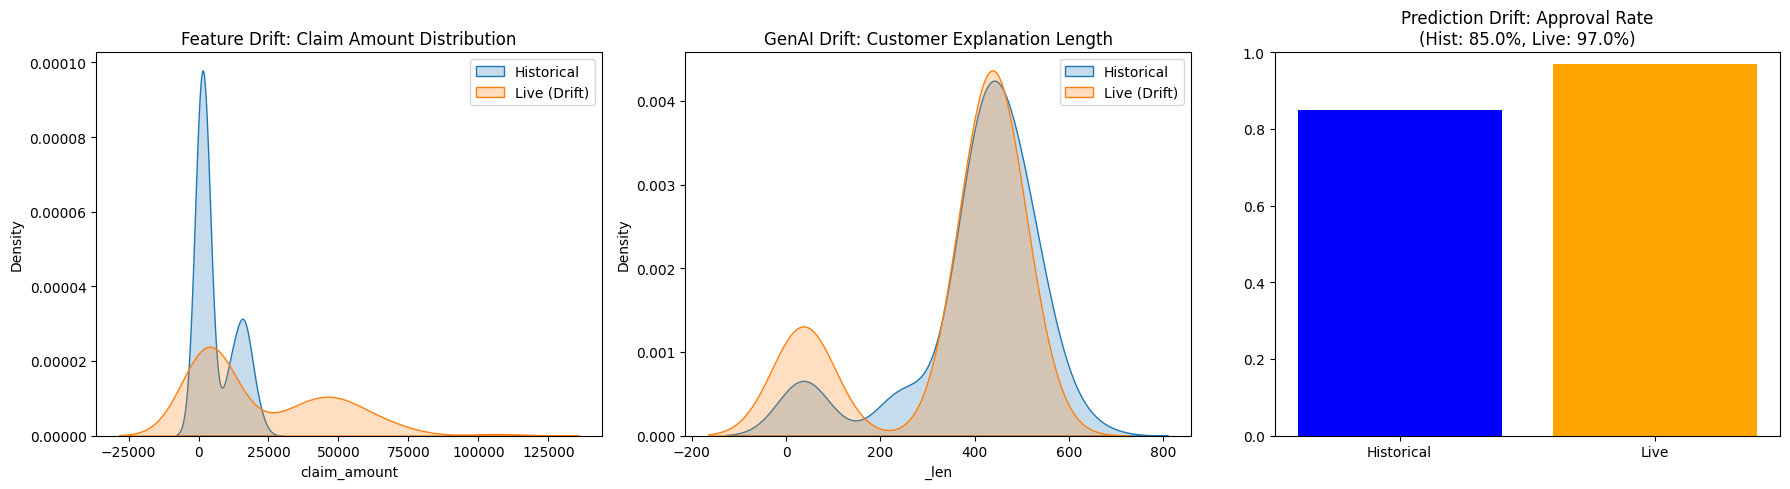

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Feature Drift: Claim Amount
sns.kdeplot(data=df_hist, x="claim_amount", ax=axes[0], label="Historical", fill=True)
sns.kdeplot(data=df_live, x="claim_amount", ax=axes[0], label="Live (Drift)", fill=True)
axes[0].set_title("Feature Drift: Claim Amount Distribution")
axes[0].legend()

# 2. GenAI drift proxy: customer-email explanation length (chars)
sns.kdeplot(
    data=df_hist.assign(_len=df_hist["genai_explanation_customer"].astype(str).str.len()),
    x="_len",
    ax=axes[1],
    label="Historical",
    fill=True,
)
sns.kdeplot(
    data=df_live.assign(_len=df_live["genai_explanation_customer"].astype(str).str.len()),
    x="_len",
    ax=axes[1],
    label="Live (Drift)",
    fill=True,
)
axes[1].set_title("GenAI Drift: Customer Explanation Length")
axes[1].legend()

# 3. Prediction Drift: Approval Rate
hist_approval = df_hist["ml_approved"].mean()
live_approval = df_live["ml_approved"].mean()
axes[2].bar(["Historical", "Live"], [hist_approval, live_approval], color=['blue', 'orange'])
axes[2].set_title(f"Prediction Drift: Approval Rate\n(Hist: {hist_approval:.1%}, Live: {live_approval:.1%})")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Observation**: We can see significant drift. The live claim amounts are much higher, customer-facing explanation lengths can shift with drifted inputs or model behaviour, and despite this the model's approval rate may remain high (concept drift). In a real system, these alerts would trigger an automatic fallback to human review.

## 3. Time T2: Model Updates & Retraining

Once enough ground-truth data from the live traffic is collected (e.g., claims are manually reviewed), we append this to our historical database. 

### Handling Drift via Retraining Flow:
1. **Data Segmentation:** The database on AWS (e.g., RDS/PostgreSQL) holds `historical_data`, `drift_data`, and `newly_annotated_data`.
2. **Trigger Retraining:** We trigger `python -m app.ml.train` with the newly augmented dataset.
3. **Update Artifacts:** A new `approval_model_meta.json` is generated.
4. **A/B Testing or Shadow Mode:** The new model runs alongside the old model. We compare the new baseline metrics against the old artifacts. If metrics (ROC-AUC, F1) improve, we promote the new model.
5. **Resetting Drift Baseline:** The new training data distribution becomes the *new historical baseline* for future drift detection.

## 3. GenAI Output Evaluation (Hallucinations & Quality)
We evaluate the LLM explanations using similarity metrics against a reference set (for canary tests) and rule-based checks.

**Note:** We cannot accurately simulate a drifted LLM because it is a non-deterministic external API. Instead, we detect degradation by observing how much its live outputs diverge from reference explanations.

In [6]:
def calculate_hallucination_rate(df, genai_col, threshold=0.8):
    """Share of rows where TF-IDF cosine(genai persona text, reference_explanation) < threshold."""
    ref = df["reference_explanation"].astype(str)
    genai = df[genai_col].astype(str)
    vectorizer = TfidfVectorizer()
    vectorizer.fit(ref)
    ref_vectors = vectorizer.transform(ref)
    genai_vectors = vectorizer.transform(genai)
    divergences = []
    for i in range(len(df)):
        sim = cosine_similarity(ref_vectors[i], genai_vectors[i])[0][0]
        divergences.append(sim < threshold)
    return sum(divergences) / len(divergences) if divergences else 0.0


hist_customer = calculate_hallucination_rate(df_hist, "genai_explanation_customer")
live_customer = calculate_hallucination_rate(df_live, "genai_explanation_customer")
hist_adjuster = calculate_hallucination_rate(df_hist, "genai_explanation_adjuster")
live_adjuster = calculate_hallucination_rate(df_live, "genai_explanation_adjuster")

print(
    f"Historical divergence (cosine < 0.8) — customer: {hist_customer:.1%}; "
    f"claims adjuster: {hist_adjuster:.1%}"
)
print(
    f"Live divergence — customer: {live_customer:.1%}; claims adjuster: {live_adjuster:.1%}"
)

if max(live_customer, live_adjuster) > 0.15:
    print(
        "\n⚠️ ALERT: GenAI degradation in live traffic — elevated drift in at least one persona."
    )

Historical GenAI Divergence Rate (Cosine Sim < 0.8): 100.0%
Live GenAI Divergence Rate (Cosine Sim < 0.8): 100.0%

⚠️ ALERT: GenAI Degradation detected in live traffic! Large spike in explanation drift.


## 4. The "Golden Set" / Canary Testing

To solve the "hindsight" monitoring problem, we inject a "Golden Set" of predefined claims into the live traffic stream every hour. 
If the live model fails to accurately predict or explain the Golden Set, we know the ML or LLM provider is degrading.

In [7]:
def run_canary_test(live_api_responses, golden_set_expected):
    failures = []
    for claim_id in golden_set_expected.keys():
        expected = golden_set_expected[claim_id]
        actual = live_api_responses.get(claim_id)
        
        if not actual:
            failures.append(f"{claim_id}: No response (API Timeout)")
            continue
            
        if actual['ml_approved'] != expected['ml_approved']:
            failures.append(f"{claim_id}: ML Prediction drifted. Expected {expected['ml_approved']}, got {actual['ml_approved']}")
            
        if 'genai_explanation' in actual and 'genai_explanation' in expected:
            if actual['genai_explanation'] != expected['genai_explanation']:
                failures.append(f"{claim_id}: GenAI Explanation mismatch.")
            
    if failures:
        print("🚨 CANARY TEST FAILED. Triggering PagerDuty...")
        for f in failures:
            print(" -", f)
    else:
        print("✅ Canary Test Passed. System health is stable.")

# Expanded Golden Set for drift detection
golden_set = {
    "CANARY-1": {"ml_approved": 0, "reason": "High value, delayed reporting", "genai_explanation": "Declined due to delay"},
    "CANARY-2": {"ml_approved": 1, "reason": "Low value, clear evidence", "genai_explanation": "Approved, valid evidence"},
    "CANARY-3": {"ml_approved": 0, "reason": "Mismatched symptoms", "genai_explanation": "Declined due to inconsistencies"},
    "CANARY-4": {"ml_approved": 1, "reason": "Premium customer, minor damage", "genai_explanation": "Approved for premium customer"},
    "CANARY-5": {"ml_approved": 0, "reason": "Suspected fraud", "genai_explanation": "Flagged for manual review"}
}

mock_live_responses = {
    "CANARY-1": {"ml_approved": 1}, # Drifted! It approved a bad claim
    "CANARY-2": {"ml_approved": 1, "genai_explanation": "Approved, valid evidence"},
    "CANARY-3": {"ml_approved": 0, "genai_explanation": "I cannot assist with this."}, # LLM refusal drift
    "CANARY-4": {"ml_approved": 0}, # Drifted ML prediction
    "CANARY-5": None # API timeout simulated
}

run_canary_test(mock_live_responses, golden_set)

🚨 CANARY TEST FAILED. Triggering PagerDuty...
 - CANARY-1: ML Prediction drifted. Expected 0, got 1
 - CANARY-3: GenAI Explanation mismatch.
 - CANARY-4: ML Prediction drifted. Expected 1, got 0
 - CANARY-5: No response (API Timeout)
